In [ ]:
# =============================================================================
# Movie Poster Genre Classification — ResNet50 + K-Fold CV + Augmentation
# =============================================================================

# ── CELL 1: IMPORTS ──────────────────────────────────────────────────────────

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import subprocess; subprocess.run(['pip', 'install', 'iterative-stratification', '-q'], check=True)
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    hamming_loss,
    accuracy_score,
    classification_report,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

c:\Main Storage\Documents\UGM\computer vision\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ── CELL 2: CONFIG & PATHS ──────────────────────────────────────────────────
from pathlib import Path
import random
import numpy as np
import torch

# --- paths (Local) ---
# Menggunakan current directory (tempat file .ipynb / .py berada)
BASE_DIR = Path(".")

TRAIN_IMG_DIR = BASE_DIR / "Datasets" / "images" / "train"
TEST_IMG_DIR  = BASE_DIR / "Datasets" / "images" / "test"
GENRE_XLSX    = BASE_DIR / "Datasets" / "genre.xlsx"

# Output akan disimpan di folder "output" di direktori yang sama
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# --- hyperparameters ---
RESNET_FEATURE_DIM = 2048  # ResNet50 output dimension

GENRE_COLS = [
    "action", "adventure", "animation", "comedy", "crime", "drama",
    "family", "fantasy", "horror", "musical", "mystery", "romance", "scifi", "thriller",
]
NUM_LABELS = len(GENRE_COLS)

N_FOLDS = 5
EPOCHS = 20
BATCH_SIZE = 16
LR = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 5
NUM_WORKERS = 0  # Tetap 0 untuk mencegah crash MultiProcessing di Windows

THRESHOLD_GRID = np.arange(0.1, 0.91, 0.01)

Device: cuda


In [3]:
# ── CELL 3: LOAD LABELS ─────────────────────────────────────────────────────

def list_images(img_dir: Path) -> list[str]:
    files = sorted(img_dir.glob("*.jpg"), key=lambda p: int(p.stem))
    return [f.name for f in files]


train_filenames = set(list_images(TRAIN_IMG_DIR))
test_filenames = sorted(list_images(TEST_IMG_DIR), key=lambda x: int(Path(x).stem))

print(f"Train images: {len(train_filenames)}")
print(f"Test images:  {len(test_filenames)}")

# Load xlsx once, then keep TRAIN rows only (prevents label leakage from test rows)
raw_df = pd.read_excel(GENRE_XLSX)
# Generate filename if not present
if "filename" not in raw_df.columns or raw_df["filename"].isna().all():
    raw_df["filename"] = [f"{i+1}.jpg" for i in range(len(raw_df))]

train_df = raw_df[raw_df["filename"].isin(train_filenames)].copy()
train_df = train_df.sort_values("filename", key=lambda s: s.str.replace(".jpg", "", regex=False).astype(int))
train_df = train_df.reset_index(drop=True)

# Sanity checks
missing = train_filenames - set(train_df["filename"])
extra = set(train_df["filename"]) - train_filenames
assert not missing, f"Train images missing labels: {missing}"
assert not extra, f"Unexpected label rows: {extra}"

overlap = set(test_filenames) & set(train_df["filename"])
assert not overlap, f"Train/test filename overlap: {overlap}"

X_train = train_df["filename"].values
y_train = train_df[GENRE_COLS].values.astype(np.float32)

print("Train label matrix:", y_train.shape)
print("Positives per genre (train only):")
print(pd.Series(y_train.sum(axis=0), index=GENRE_COLS).astype(int))


Train images: 250
Test images:  50
Train label matrix: (250, 14)
Positives per genre (train only):
action       167
adventure    125
animation     47
comedy        80
crime         48
drama        146
family        35
fantasy       71
horror        22
musical        5
mystery       41
romance       38
scifi         72
thriller      75
dtype: int64


In [4]:
# ── CELL 4: DATASET & TRANSFORMS ────────────────────────────────────────────

# ImageNet normalization (standar untuk ResNet)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class PosterDataset(Dataset):
    def __init__(self, img_dir: Path, filenames, labels=None, transform=None):
        self.img_dir = Path(img_dir)
        self.filenames = list(filenames)
        self.labels = None if labels is None else torch.tensor(labels, dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        path = self.img_dir / name
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.labels is None:
            return image, name
        return image, self.labels[idx], name


def collate_train(batch):
    pixels = torch.stack([b[0] for b in batch])
    labels = torch.stack([b[1] for b in batch])
    names = [b[2] for b in batch]
    return pixels, labels, names


def collate_infer(batch):
    pixels = torch.stack([b[0] for b in batch])
    names = [b[1] for b in batch]
    return pixels, names

In [5]:
# ── CELL 5: MODEL ARCHITECTURE ──────────────────────────────────────────────

class ResNet50MultiLabelClassifier(nn.Module):
    """Frozen ResNet50 encoder + trainable head (14 logits)."""

    def __init__(self, num_labels: int, feature_dim: int = 2048, freeze_encoder: bool = True):
        super().__init__()

        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        # Remove original classification head
        self.resnet.fc = nn.Identity()

        if freeze_encoder:
            for param in self.resnet.parameters():
                param.requires_grad = False
            # Unfreeze last residual block (layer4) for partial fine-tuning
            for param in self.resnet.layer4.parameters():
                param.requires_grad = True

        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Dropout(0.3),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_labels),
        )

    def forward(self, pixel_values):
        features = self.resnet(pixel_values)  # (batch, 2048)
        logits = self.head(features)
        return logits

In [6]:
# ── CELL 6: UTILITY FUNCTIONS ───────────────────────────────────────────────

def compute_pos_weight(y: np.ndarray) -> torch.Tensor:
    """BCE pos_weight = num_neg / num_pos per class (from training split only)."""
    pos = y.sum(axis=0)
    neg = len(y) - pos
    weights = neg / np.clip(pos, 1.0, None)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def tune_thresholds(y_true: np.ndarray, y_prob: np.ndarray, grid=THRESHOLD_GRID) -> np.ndarray:
    """Per-genre threshold maximizing F1 on validation predictions."""
    thresholds = np.full(y_true.shape[1], 0.5, dtype=np.float32)
    for j in range(y_true.shape[1]):
        best_f1, best_t = -1.0, 0.5
        col_true = y_true[:, j]
        col_prob = y_prob[:, j]
        if col_true.sum() == 0:
            thresholds[j] = 0.5
            continue
        for t in grid:
            pred = (col_prob >= t).astype(int)
            f1 = f1_score(col_true, pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[j] = best_t
    return thresholds


def apply_thresholds(y_prob: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    return (y_prob >= thresholds.reshape(1, -1)).astype(int)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    return {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "mAP_macro": average_precision_score(y_true, y_prob, average="macro"),
    }


@torch.no_grad()
def predict_probs(model, loader) -> tuple[np.ndarray, list[str]]:
    model.eval()
    all_probs, all_names = [], []
    for batch in loader:
        if len(batch) == 3:
            pixels, _, names = batch
        else:
            pixels, names = batch
        pixels = pixels.to(DEVICE)
        logits = model(pixels)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_names.extend(names)
    return np.vstack(all_probs), all_names

In [7]:
# ── CELL 7: K-FOLD TRAINING ─────────────────────────────────────────────────

def train_one_fold(fold_idx, train_idx, val_idx):
    print(f"\n{'='*60}\nFold {fold_idx + 1}/{N_FOLDS}\n{'='*60}")

    y_tr, y_va = y_train[train_idx], y_train[val_idx]
    files_tr, files_va = X_train[train_idx], X_train[val_idx]

    pos_weight = compute_pos_weight(y_tr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_ds = PosterDataset(TRAIN_IMG_DIR, files_tr, y_tr, transform=train_transform)
    val_ds   = PosterDataset(TRAIN_IMG_DIR, files_va, y_va, transform=val_transform)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, collate_fn=collate_train, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=collate_train, pin_memory=True,
    )

    model = ResNet50MultiLabelClassifier(
        NUM_LABELS, RESNET_FEATURE_DIM, freeze_encoder=True
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY,
    )

    best_val_f1 = -1.0
    best_state = None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []
        for pixels, labels, _ in train_loader:
            pixels, labels = pixels.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(pixels)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_probs, _ = predict_probs(model, val_loader)
        val_pred_default = (val_probs >= 0.5).astype(int)
        val_metrics = compute_metrics(y_va, val_pred_default, val_probs)

        print(
            f"Epoch {epoch:02d} | loss {np.mean(train_losses):.4f} | "
            f"val F1 macro {val_metrics['f1_macro']:.4f} | val F1 micro {val_metrics['f1_micro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP_PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)

    val_probs, _ = predict_probs(model, val_loader)
    fold_thresholds = tune_thresholds(y_va, val_probs)
    val_pred_tuned = apply_thresholds(val_probs, fold_thresholds)

    metrics_default = compute_metrics(y_va, (val_probs >= 0.5).astype(int), val_probs)
    metrics_tuned = compute_metrics(y_va, val_pred_tuned, val_probs)

    print("Fold metrics @0.5:", metrics_default)
    print("Fold metrics @tuned thresholds:", metrics_tuned)
    print("Fold thresholds:", dict(zip(GENRE_COLS, fold_thresholds.round(3))))

    return {
        "model_state": best_state,
        "thresholds": fold_thresholds,
        "metrics_default": metrics_default,
        "metrics_tuned": metrics_tuned,
    }


# Run K-Fold
kf = MultilabelStratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    result = train_one_fold(fold_idx, train_idx, val_idx)
    fold_results.append(result)

cv_default = pd.DataFrame([r["metrics_default"] for r in fold_results])
cv_tuned = pd.DataFrame([r["metrics_tuned"] for r in fold_results])

print("\n=== CV summary (threshold 0.5) ===")
print(cv_default.mean().round(4))
print("\n=== CV summary (tuned thresholds) ===")
print(cv_tuned.mean().round(4))

# Aggregate thresholds: median across folds
threshold_matrix = np.stack([r["thresholds"] for r in fold_results])
FINAL_THRESHOLDS = np.median(threshold_matrix, axis=0)
print("\nFinal thresholds (median over folds):")
for g, t in zip(GENRE_COLS, FINAL_THRESHOLDS):
    print(f"  {g:12s}: {t:.2f}")



Fold 1/5
Epoch 01 | loss 1.0408 | val F1 macro 0.4140 | val F1 micro 0.4619
Epoch 02 | loss 0.9175 | val F1 macro 0.4330 | val F1 micro 0.4639
Epoch 03 | loss 0.8829 | val F1 macro 0.4581 | val F1 micro 0.4900
Epoch 04 | loss 0.8248 | val F1 macro 0.4697 | val F1 micro 0.5112
Epoch 05 | loss 0.7807 | val F1 macro 0.4703 | val F1 micro 0.5208
Epoch 06 | loss 0.7213 | val F1 macro 0.4791 | val F1 micro 0.5245
Epoch 07 | loss 0.6673 | val F1 macro 0.5162 | val F1 micro 0.5575
Epoch 08 | loss 0.6274 | val F1 macro 0.5546 | val F1 micro 0.5793
Epoch 09 | loss 0.5901 | val F1 macro 0.4842 | val F1 micro 0.5869
Epoch 10 | loss 0.5430 | val F1 macro 0.4798 | val F1 micro 0.5928
Epoch 11 | loss 0.4907 | val F1 macro 0.4924 | val F1 micro 0.6029
Epoch 12 | loss 0.4372 | val F1 macro 0.4745 | val F1 micro 0.5952
Epoch 13 | loss 0.4173 | val F1 macro 0.4876 | val F1 micro 0.5980
Early stopping at epoch 13
Fold metrics @0.5: {'f1_macro': 0.5545592193961417, 'f1_micro': 0.5793103448275863, 'precisi

In [33]:
# ── CELL 8: FINAL MODEL (TRAIN ON ALL 250 IMAGES) ───────────────────────────

pos_weight_full = compute_pos_weight(y_train)
criterion_full = nn.BCEWithLogitsLoss(pos_weight=pos_weight_full)

full_ds = PosterDataset(TRAIN_IMG_DIR, X_train, y_train, transform=train_transform)
full_loader = DataLoader(
    full_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_train, pin_memory=True,
)

final_model = ResNet50MultiLabelClassifier(
    NUM_LABELS, RESNET_FEATURE_DIM, freeze_encoder=True
).to(DEVICE)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, final_model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

best_loss = float("inf")
best_final_state = None
patience = 0
train_history = []  # Track loss per epoch

for epoch in range(1, EPOCHS + 1):
    final_model.train()
    losses = []
    for pixels, labels, _ in tqdm(full_loader, desc=f"Final train epoch {epoch}", leave=False):
        pixels, labels = pixels.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = final_model(pixels)
        loss = criterion_full(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    epoch_loss = np.mean(losses)
    print(f"Epoch {epoch:02d} | train loss {epoch_loss:.4f}")
    train_history.append(epoch_loss)


    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_final_state = {k: v.cpu().clone() for k, v in final_model.state_dict().items()}
        patience = 0
    else:
        patience += 1
        if patience >= EARLY_STOP_PATIENCE:
            print("Early stopping final model")
            break

final_model.load_state_dict(best_final_state)
final_model.to(DEVICE)
print("Final model trained on all", len(X_train), "images")

Epoch 01 | train loss 0.9981


Epoch 02 | train loss 0.9113


Epoch 03 | train loss 0.8518


Epoch 04 | train loss 0.7951


Epoch 05 | train loss 0.7277


...

Epoch 16 | train loss 0.2739


Epoch 17 | train loss 0.2679


Epoch 18 | train loss 0.2335


Epoch 19 | train loss 0.2049


Epoch 20 | train loss 0.1989
Final model trained on all 250 images


In [34]:
# ── CELL 9: INFERENCE ON TEST SET ────────────────────────────────────────────

test_ds = PosterDataset(TEST_IMG_DIR, test_filenames, labels=None, transform=val_transform)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_infer, pin_memory=True,
)

test_probs, test_names_out = predict_probs(final_model, test_loader)
assert test_names_out == test_filenames, "Test prediction order mismatch"

test_pred = apply_thresholds(test_probs, FINAL_THRESHOLDS)

submission = pd.DataFrame(test_pred, columns=GENRE_COLS)
submission.insert(0, "filename", test_filenames)

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved submission: {submission_path}")
print(submission.head())
print("\nPredicted positives per genre:")
print(submission[GENRE_COLS].sum())

Saved submission: output\submission.csv
  filename  action  adventure  animation  comedy  crime  drama  family  \
0  251.jpg       1          0          0       0      1      1       0   
1  252.jpg       0          1          1       1      0      0       1   
2  253.jpg       0          1          1       1      0      0       1   
3  254.jpg       1          0          0       0      0      1       0   
4  255.jpg       1          1          0       0      0      1       0   

   fantasy  horror  musical  mystery  romance  scifi  thriller  
0        0       0        0        1        0      1         1  
1        1       1        0        1        0      0         0  
2        1       0        1        1        0      0         0  
3        1       0        0        0        1      0         0  
4        0       0        0        0        0      1         0  

Predicted positives per genre:
action       37
adventure    18
animation     7
comedy       14
crime        13
drama        

In [35]:
# ── CELL 10: SAVE MODEL CHECKPOINT ──────────────────────────────────────────

model_save_path = OUTPUT_DIR / "resnet50_multilabel_poster_model.pt"

checkpoint = {
    "model_name": "ResNet50",
    "genre_cols": GENRE_COLS,
    "state_dict": best_final_state,
    "thresholds": FINAL_THRESHOLDS.tolist(),
    "cv_metrics_default_mean": cv_default.mean().to_dict(),
    "cv_metrics_tuned_mean": cv_tuned.mean().to_dict(),
    "hyperparameters": {
        "n_folds": N_FOLDS,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "seed": SEED,
    },
}

torch.save(checkpoint, model_save_path)
print(f"Saved model checkpoint: {model_save_path}")

with open(OUTPUT_DIR / "thresholds.json", "w") as f:
    json.dump(dict(zip(GENRE_COLS, FINAL_THRESHOLDS.tolist())), f, indent=2)

cv_default.to_csv(OUTPUT_DIR / "cv_fold_metrics_default.csv", index=False)
cv_tuned.to_csv(OUTPUT_DIR / "cv_fold_metrics_tuned.csv", index=False)
print("Also saved thresholds.json and per-fold CV metric CSVs")

Saved model checkpoint: output\resnet50_multilabel_poster_model.pt
Also saved thresholds.json and per-fold CV metric CSVs


In [36]:
# ── CELL 11: TEST SET EVALUATION ────────────────────────────────────────────

# Match ground truth test rows by filename
ground_truth = raw_df[raw_df["filename"].isin(test_filenames)].copy()
ground_truth = ground_truth.sort_values(
    "filename",
    key=lambda s: s.str.replace(".jpg", "", regex=False).astype(int)
).reset_index(drop=True)

submission_sorted = submission.sort_values(
    "filename",
    key=lambda s: s.str.replace(".jpg", "", regex=False).astype(int)
).reset_index(drop=True)

y_true = ground_truth[GENRE_COLS].values.astype(int)
y_pred = submission_sorted[GENRE_COLS].values.astype(int)

print("\n===================================================")
print("TEST SET EVALUATION Resnet50")
print("===================================================")

binary_acc = (y_true == y_pred).mean()
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
micro_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
micro_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
ham_loss = hamming_loss(y_true, y_pred)

print(f"Binary Accuracy : {binary_acc:.4f}")
print(f"Micro F1        : {micro_f1:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Micro Precision : {micro_precision:.4f}")
print(f"Micro Recall    : {micro_recall:.4f}")
print(f"Hamming Loss    : {ham_loss:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=GENRE_COLS, zero_division=0))



TEST SET EVALUATION Resnet50
Binary Accuracy : 0.8186
Micro F1        : 0.6880
Macro F1        : 0.5360
Micro Precision : 0.6542
Micro Recall    : 0.7254
Hamming Loss    : 0.1814

Classification Report:
              precision    recall  f1-score   support

      action       0.78      0.81      0.79        36
   adventure       0.78      0.64      0.70        22
   animation       1.00      0.88      0.93         8
      comedy       0.64      0.69      0.67        13
       crime       0.62      0.62      0.62        13
       drama       0.81      1.00      0.89        34
      family       0.40      0.50      0.44         4
     fantasy       0.50      0.55      0.52        11
      horror       0.14      0.33      0.20         3
     musical       0.00      0.00      0.00         0
     mystery       0.41      0.54      0.47        13
     romance       0.00      0.00      0.00         1
       scifi       0.53      0.57      0.55        14
    thriller       0.71      0.71      

In [37]:
# ── CELL 12: SAVE PREDICTIONS ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Build test_predictions.csv
results = pd.DataFrame({"filename": test_filenames})

# Tambah title dari raw_df jika ada
if "title" in raw_df.columns:
    title_map = dict(zip(raw_df["filename"], raw_df["title"]))
    results["title"] = results["filename"].map(title_map).fillna("Unknown")

# Probabilities & predictions per genre
for i, genre in enumerate(GENRE_COLS):
    results[f"{genre}_prob"] = test_probs[:, i].round(4)
    results[f"{genre}_pred"] = test_pred[:, i]

def get_predicted_genres(row):
    genres = [g for g in GENRE_COLS if row[f"{g}_pred"] == 1]
    return ", ".join(genres) if genres else "none"

def get_actual_genres(idx):
    genres = [g for g, v in zip(GENRE_COLS, y_true[idx]) if v == 1]
    return ", ".join(genres) if genres else "none"

results["predicted_genres"] = results.apply(get_predicted_genres, axis=1)
results["actual_genres"] = [get_actual_genres(i) for i in range(len(y_true))]

csv_path = OUTPUT_DIR / "test_predictions.csv"
results.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# Print sample predictions
print("\nSample Predictions:")
print("-" * 80)
for idx in range(min(10, len(results))):
    row = results.iloc[idx]
    title = row.get("title", row["filename"])
    print(f"  {row['filename']:10s} | {str(title):35s}")
    print(f"  {'':10s} | Actual   : {row['actual_genres']}")
    print(f"  {'':10s} | Predicted: {row['predicted_genres']}")
    print(f"  {'':10s} |")


Saved: output\test_predictions.csv

Sample Predictions:
--------------------------------------------------------------------------------
  251.jpg    | Memento                            
             | Actual   : drama, mystery, thriller
             | Predicted: action, crime, drama, mystery, scifi, thriller
             |
  252.jpg    | Teenage Mutant Ninja Turtles       
             | Actual   : action, adventure, animation, comedy, crime, family, mystery
             | Predicted: adventure, animation, comedy, family, fantasy, horror, mystery
             |
  253.jpg    | Big Mouth                          
             | Actual   : animation, comedy, romance
             | Predicted: adventure, animation, comedy, family, fantasy, musical, mystery
             |
  254.jpg    | Gyeongseong Creature               
             | Actual   : action, drama, horror, mystery, thriller
             | Predicted: action, drama, fantasy, romance
             |
  255.jpg    | Punisher        

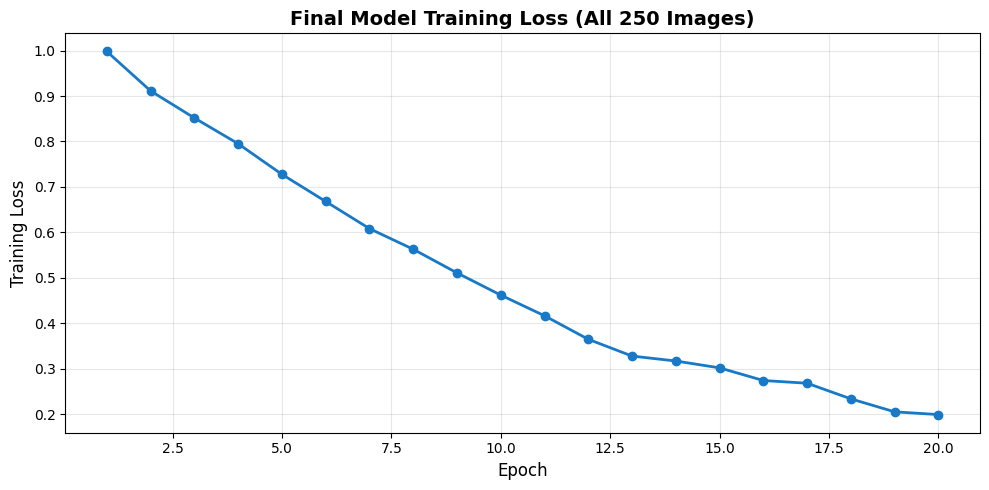

Saved: training_history.png


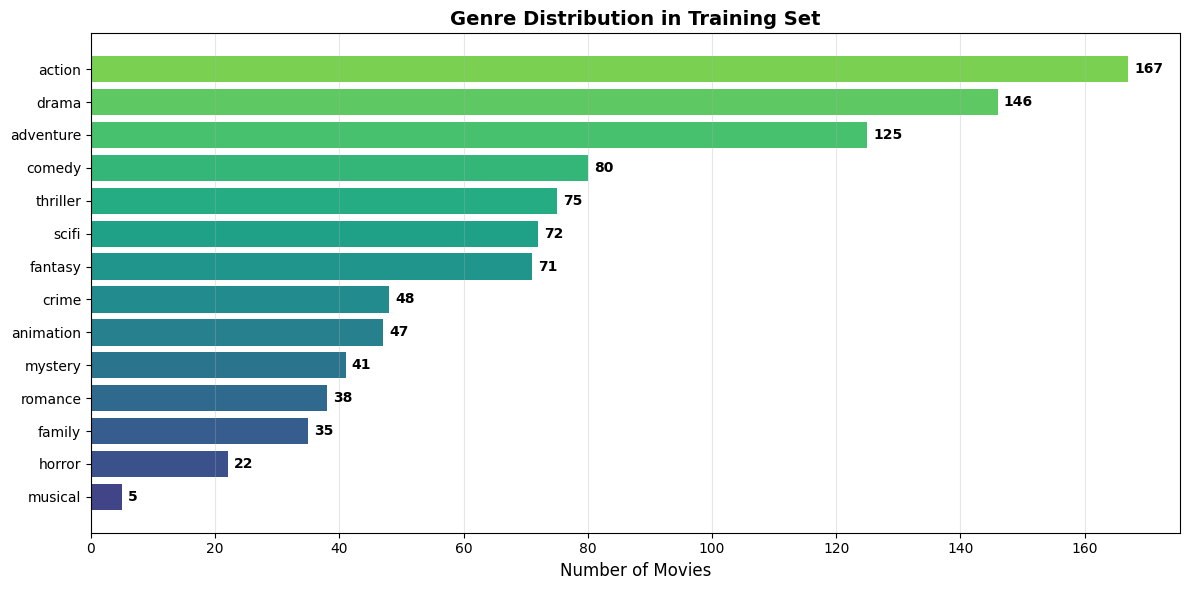

Saved: genre_distribution.png


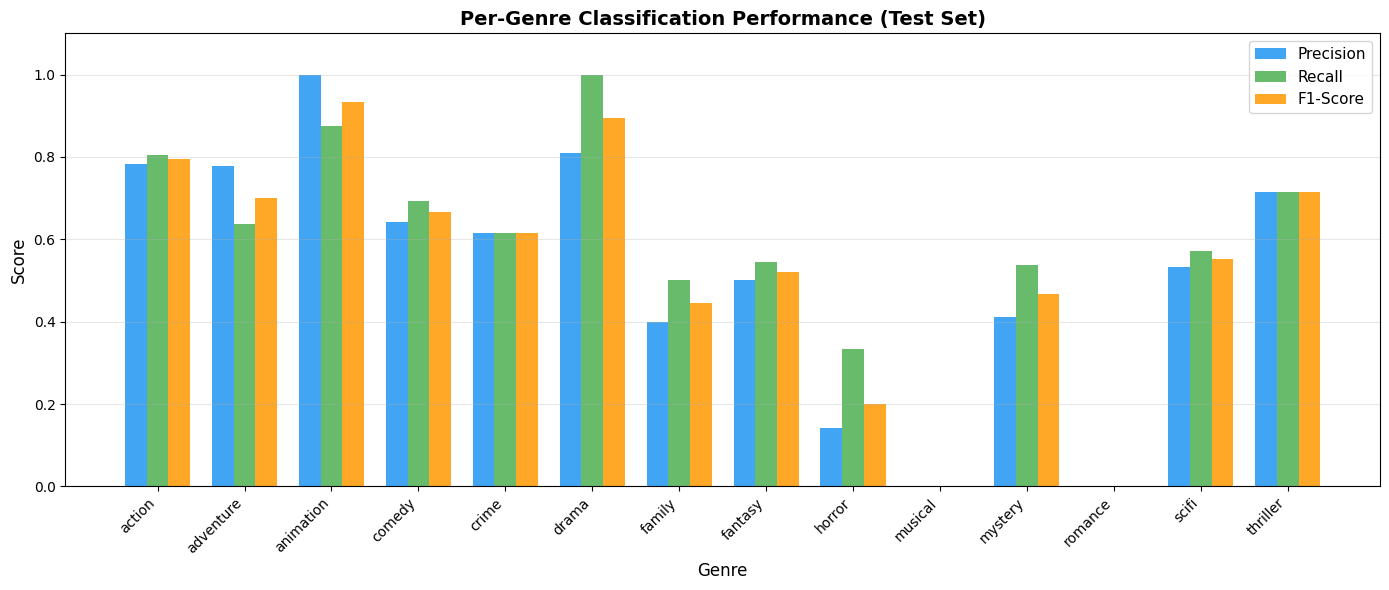

Saved: per_genre_performance.png


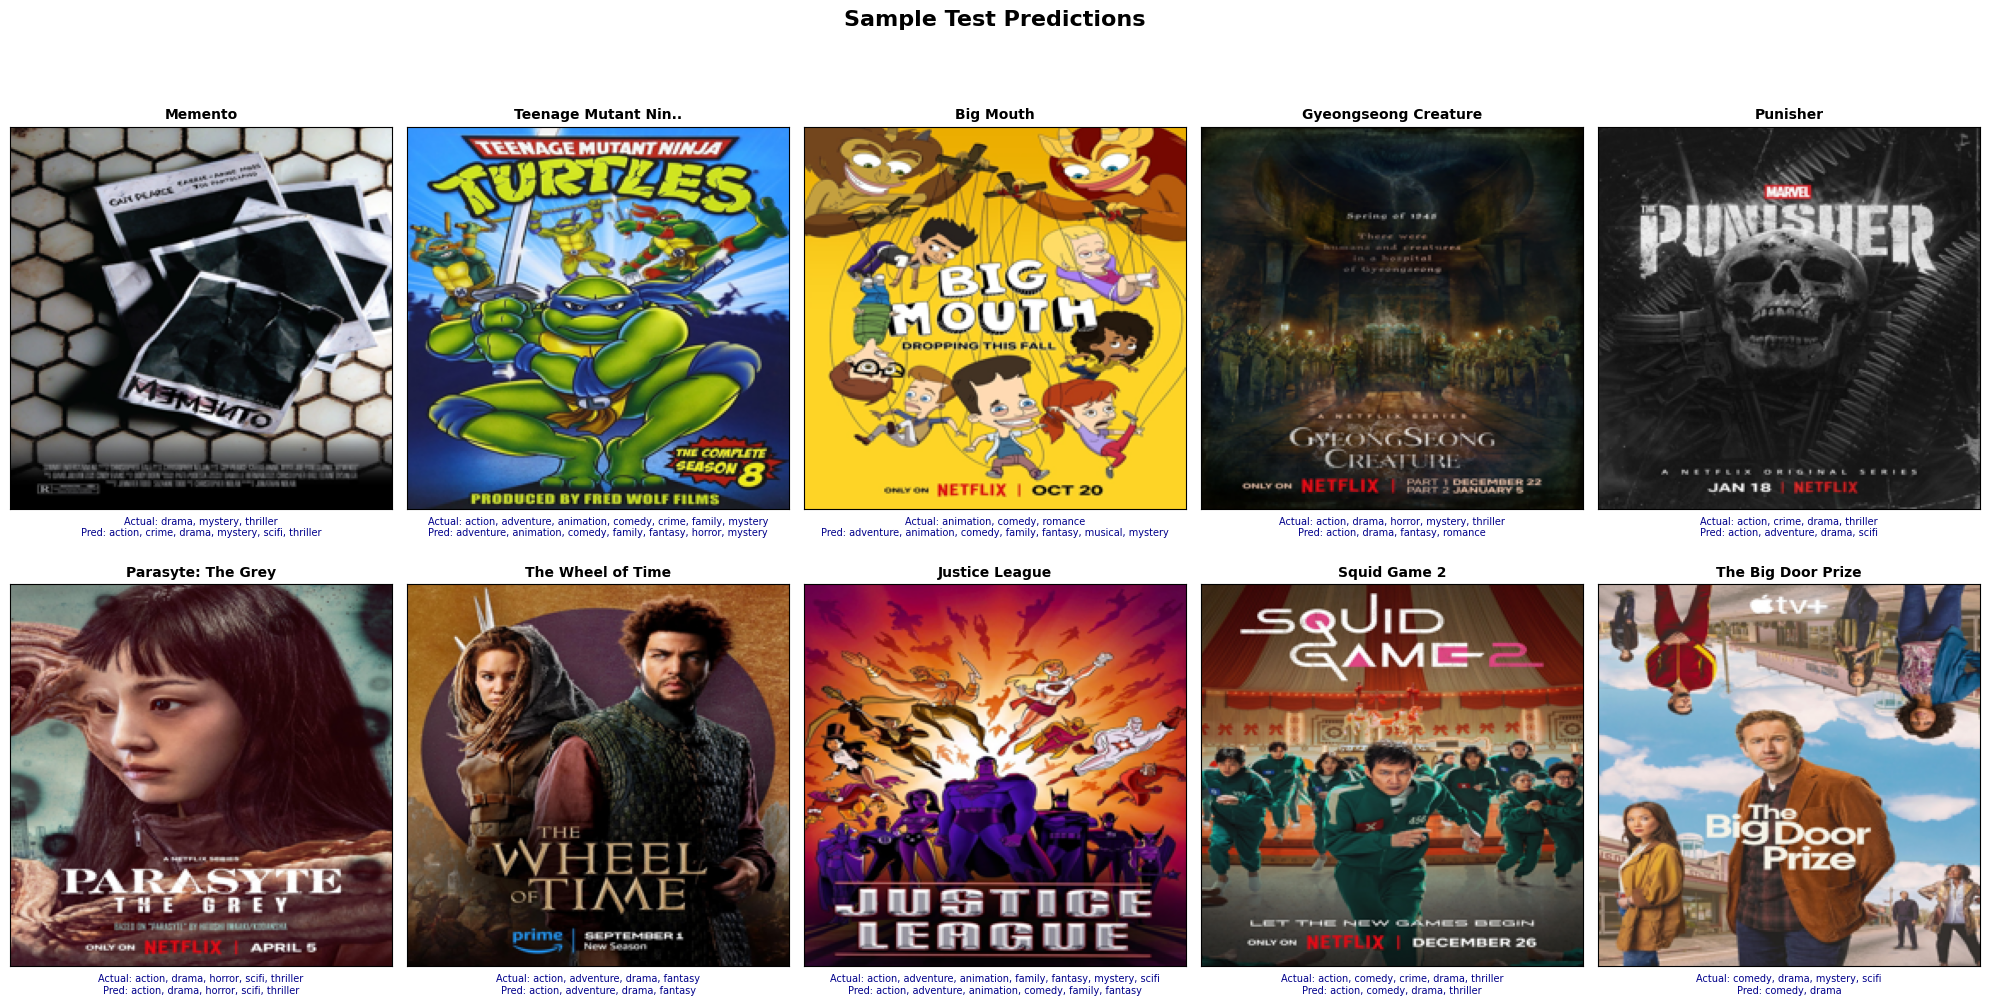

Saved: sample_predictions.png


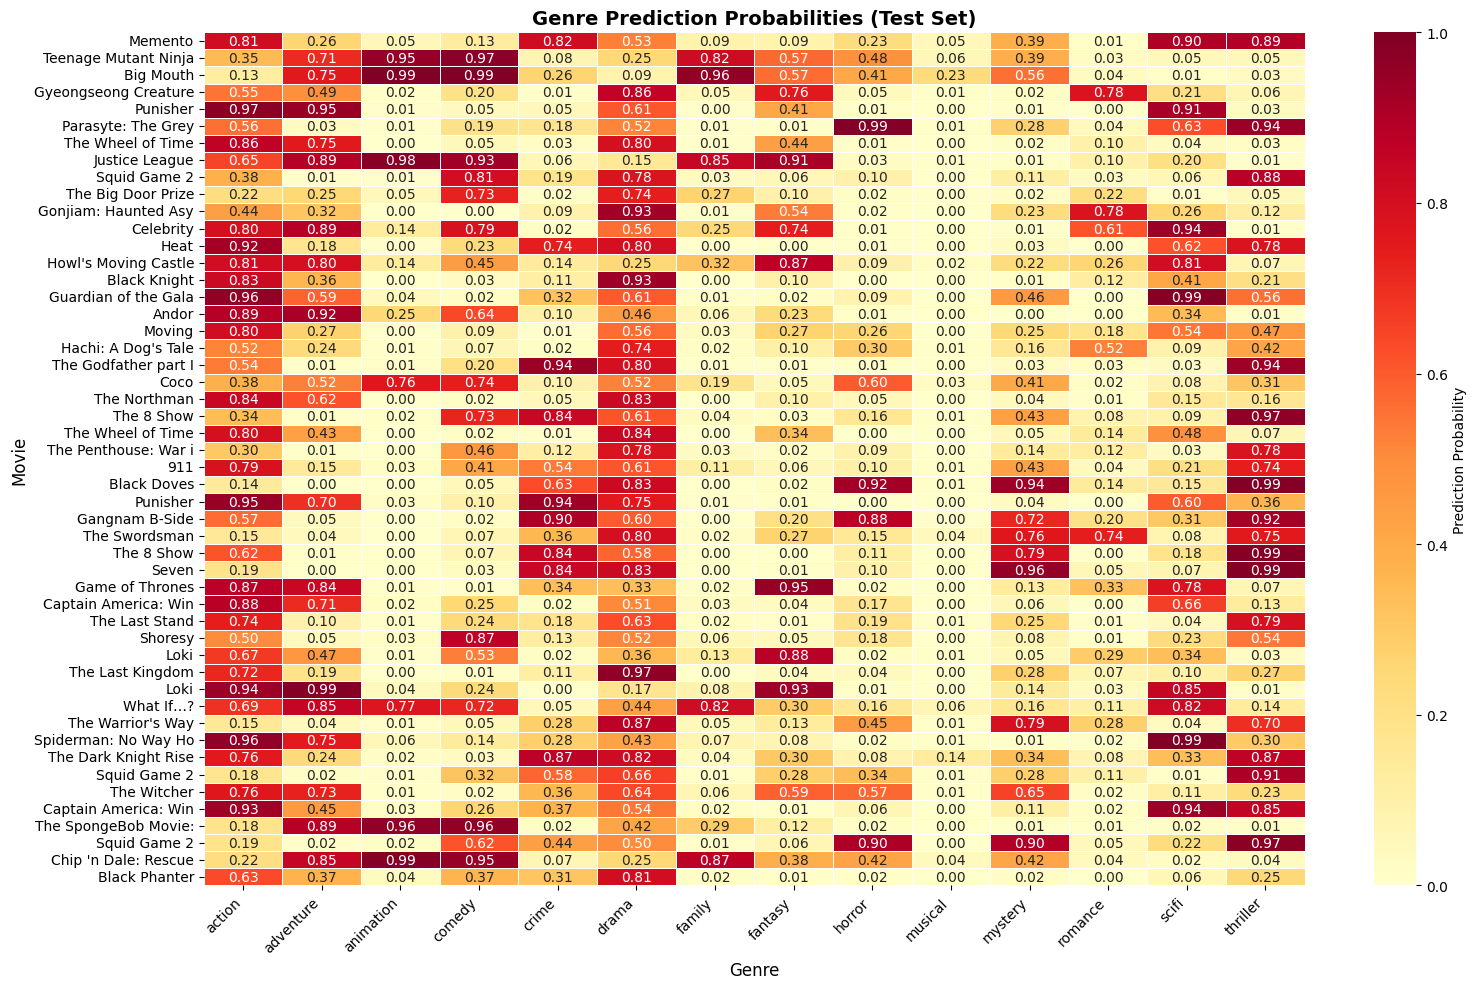

Saved: prediction_heatmap.png


In [38]:
# ── CELL 13: VISUALIZATIONS ─────────────────────────────────────────────────

# --- Plot 1: Training History (Final Model) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_history)+1), train_history, marker='o', linewidth=2, color="#1879C8")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Final Model Training Loss (All 250 Images)", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_history.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_history.png")

# --- Plot 2: Genre Distribution ---
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, NUM_LABELS))
genre_counts = pd.Series(y_train.sum(axis=0), index=GENRE_COLS).sort_values(ascending=True)
bars = ax.barh(genre_counts.index, genre_counts.values, color=colors)
ax.set_xlabel("Number of Movies", fontsize=12)
ax.set_title("Genre Distribution in Training Set", fontsize=14, fontweight='bold')
for bar, val in zip(bars, genre_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f"{int(val)}",
            va='center', fontsize=10, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "genre_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: genre_distribution.png")

# --- Plot 3: Per-Genre Performance (Test Set) ---
fig, ax = plt.subplots(figsize=(14, 6))
report_dict = classification_report(y_true, y_pred, target_names=GENRE_COLS, output_dict=True, zero_division=0)
x_pos = np.arange(NUM_LABELS)
width = 0.25

precision_vals = [report_dict[g]["precision"] for g in GENRE_COLS]
recall_vals = [report_dict[g]["recall"] for g in GENRE_COLS]
f1_vals = [report_dict[g]["f1-score"] for g in GENRE_COLS]

ax.bar(x_pos - width, precision_vals, width, label="Precision", color="#2196F3", alpha=0.85)
ax.bar(x_pos, recall_vals, width, label="Recall", color="#4CAF50", alpha=0.85)
ax.bar(x_pos + width, f1_vals, width, label="F1-Score", color="#FF9800", alpha=0.85)

ax.set_xlabel("Genre", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Per-Genre Classification Performance (Test Set)", fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(GENRE_COLS, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_genre_performance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_genre_performance.png")

# --- Plot 4: Sample Predictions with Poster Images ---
fig, axes_img = plt.subplots(2, 5, figsize=(20, 10))
axes_img = axes_img.flatten()

for i in range(min(10, len(test_filenames))):
    img_path = TEST_IMG_DIR / test_filenames[i]
    if img_path.exists():
        img = Image.open(img_path).convert("RGB").resize((224, 224))
        axes_img[i].imshow(img)

    title = results.iloc[i].get("title", test_filenames[i])
    actual = results.iloc[i]["actual_genres"]
    predicted = results.iloc[i]["predicted_genres"]
    if len(str(title)) > 20:
        title = str(title)[:18] + ".."

    axes_img[i].set_title(f"{title}", fontsize=10, fontweight='bold')
    axes_img[i].set_xlabel(f"Actual: {actual}\nPred: {predicted}", fontsize=7, color='darkblue', labelpad=5)
    axes_img[i].set_xticks([])
    axes_img[i].set_yticks([])

plt.suptitle("Sample Test Predictions", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_predictions.png")

# --- Plot 5: Prediction Heatmap ---
fig, ax = plt.subplots(figsize=(16, 10))
heatmap_data = pd.DataFrame(
    test_probs,
    columns=GENRE_COLS,
    index=[results.iloc[i].get("title", test_filenames[i])[:20] for i in range(len(test_filenames))]
)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd",
            ax=ax, vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Prediction Probability"})
ax.set_title("Genre Prediction Probabilities (Test Set)", fontsize=14, fontweight='bold')
ax.set_ylabel("Movie", fontsize=12)
ax.set_xlabel("Genre", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prediction_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: prediction_heatmap.png")
